# 모델 1: 로지스틱 회귀 (Logistic Regression)

이 노트북은 `ModelTrainer`를 활용하여 표준화된 데이터 파이프라인을 구축하고, 주가 방향을 예측하는 로지스틱 회귀 베이스라인 모델을 학습합니다.

In [7]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root / "src"))
from model_trainer import ModelTrainer

## 1. 데이터 로드 및 준비

`ModelTrainer` 클래스를 통해 로드, 분할, 스케일링이 완료된 데이터를 가져옵니다.

In [8]:
trainer = ModelTrainer()

(X_train, y_train), (X_val, y_val), (X_test, y_test) = trainer.get_prepared_data()
model_df = trainer._load_and_preprocess()

print(f"Train: {len(X_train)}")
print(f"Val: {len(X_val)}")
print(f"Test: {len(X_test)}")

Train: 914
Val: 196
Test: 197


## 1-1. EDA 및 분포 시각화

학습 데이터의 타깃 분포, 기업별 표본 구성, 검색 트렌드와 수익률 피처 분포를 확인합니다.

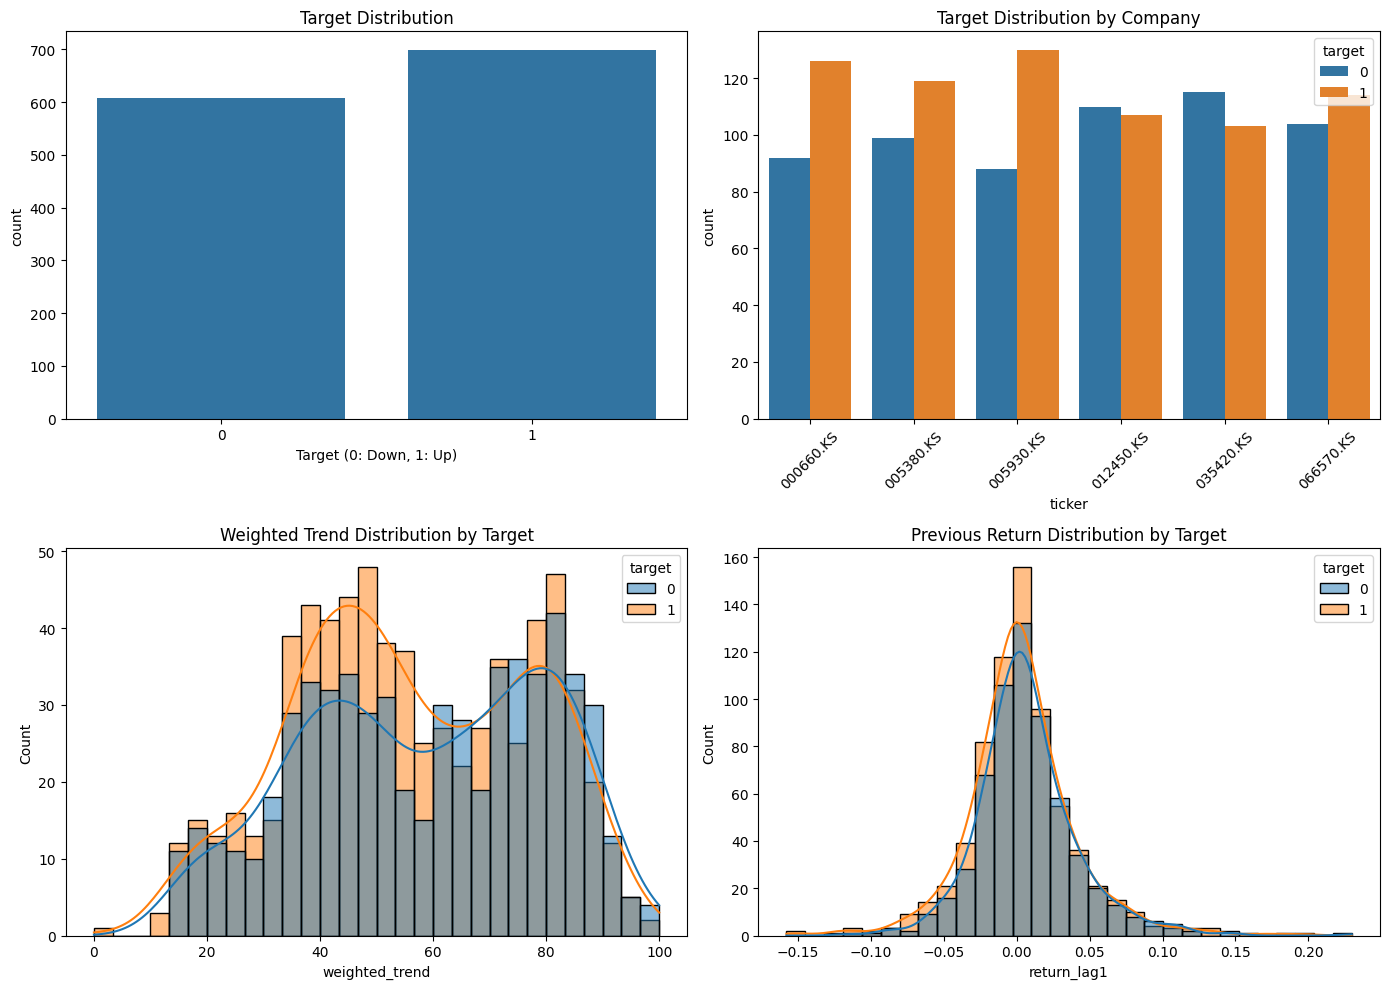

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=model_df, x="target", ax=axes[0, 0])
axes[0, 0].set_title("Target Distribution")
axes[0, 0].set_xlabel("Target (0: Down, 1: Up)")

sns.countplot(data=model_df, x="ticker", hue="target", ax=axes[0, 1])
axes[0, 1].set_title("Target Distribution by Company")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.histplot(data=model_df, x="weighted_trend", hue="target", bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Weighted Trend Distribution by Target")

sns.histplot(data=model_df, x="return_lag1", hue="target", bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Previous Return Distribution by Target")

plt.tight_layout()
plt.show()

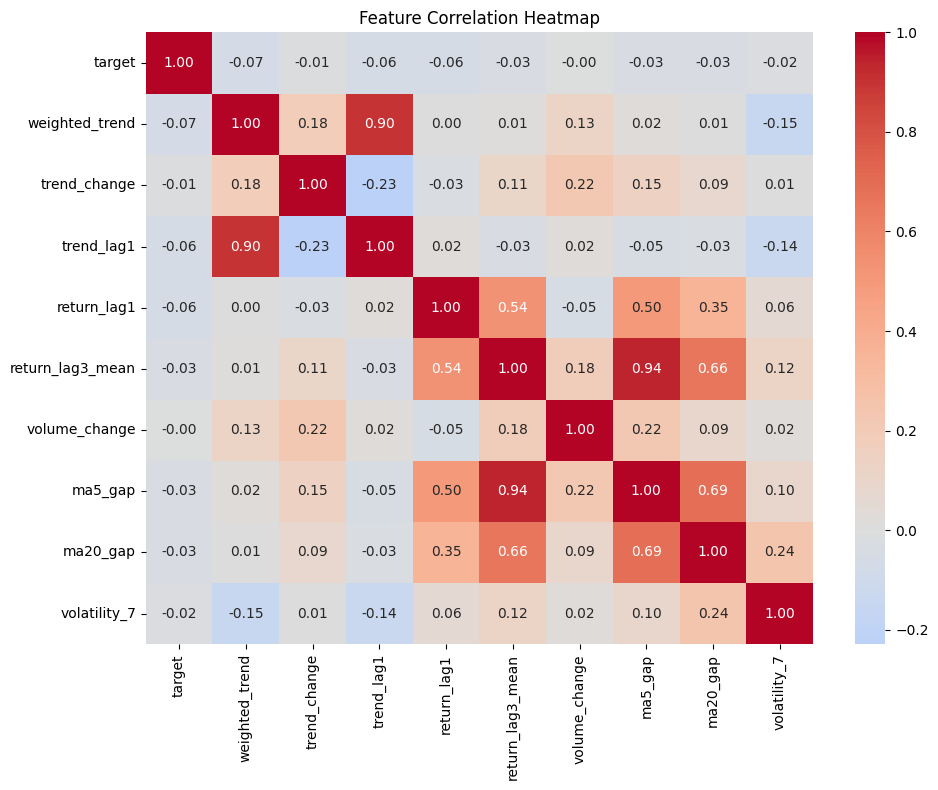

In [10]:
corr_features = [
    "target", "weighted_trend", "trend_change", "trend_lag1",
    "return_lag1", "return_lag3_mean", "volume_change",
    "ma5_gap", "ma20_gap", "volatility_7"
]

plt.figure(figsize=(10, 8))
sns.heatmap(model_df[corr_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 2. 모델 학습 및 교차 검증

시계열 교차 검증 중...
Fold 1: Accuracy = 0.4868
Fold 2: Accuracy = 0.4934
Fold 3: Accuracy = 0.4737
Fold 4: Accuracy = 0.5461
Fold 5: Accuracy = 0.5066
Average CV Accuracy: 0.5013


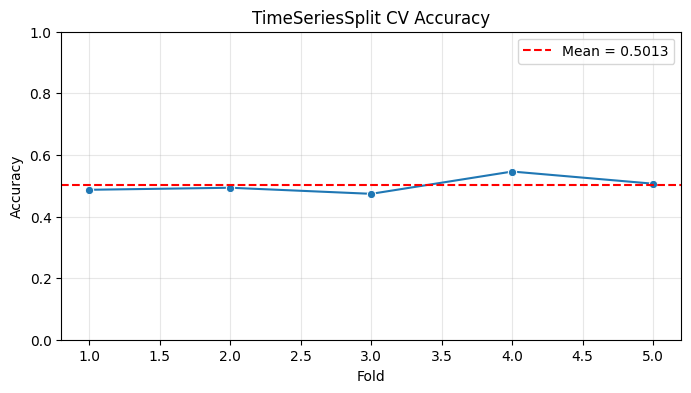

In [11]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

print("시계열 교차 검증 중...")

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_train), start=1):
    cv_model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    cv_model.fit(X_train[tr_idx], y_train.iloc[tr_idx])
    score = cv_model.score(X_train[te_idx], y_train.iloc[te_idx])

    cv_scores.append(score)
    print(f"Fold {fold}: Accuracy = {score:.4f}")

print(f"Average CV Accuracy: {np.mean(cv_scores):.4f}")

plt.figure(figsize=(8, 4))
sns.lineplot(x=list(range(1, len(cv_scores) + 1)), y=cv_scores, marker="o")
plt.axhline(np.mean(cv_scores), linestyle="--", color="red", label=f"Mean = {np.mean(cv_scores):.4f}")
plt.title("TimeSeriesSplit CV Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

final_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_train_val, y_train_val)

print("최종 모델 학습 완료")

최종 모델 학습 완료


## 3. 모델 평가

최종 평가는 정확도, Precision, Recall, F1 Score, Confusion Matrix, ROC-AUC를 기준으로 확인합니다.


[Logistic Regression Test Set 성능 평가]
Accuracy : 0.4924
Precision: 0.5333
Recall   : 0.4528
F1 Score : 0.4898
ROC-AUC  : 0.4857

[Classification Report]
              precision    recall  f1-score   support

           0       0.46      0.54      0.49        91
           1       0.53      0.45      0.49       106

    accuracy                           0.49       197
   macro avg       0.50      0.50      0.49       197
weighted avg       0.50      0.49      0.49       197



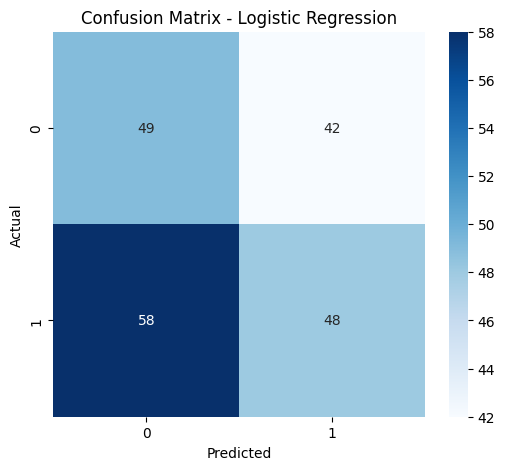

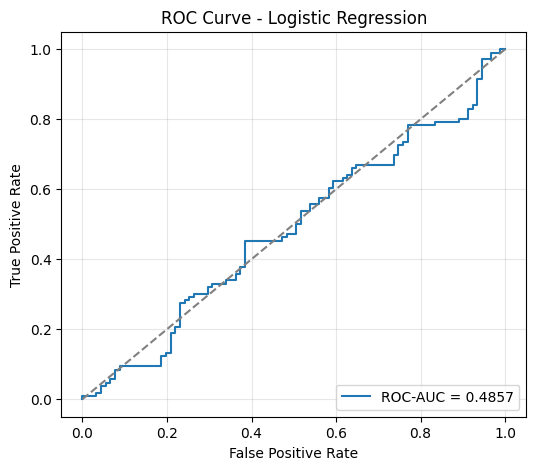

{'accuracy': 0.49238578680203043,
 'precision': 0.5333333333333333,
 'recall': 0.4528301886792453,
 'f1_score': 0.4897959183673469,
 'roc_auc': 0.4856935517312876}

In [13]:
y_pred, test_metrics = trainer.evaluate_model(
    final_model,
    X_test,
    y_test,
    "Logistic Regression"
)

test_metrics

## 3-1. 중요 변수, 과적합/언더피팅, 하이퍼파라미터 효과

로지스틱 회귀의 계수, 예측 확률 분포, 학습 곡선, C 값 변화를 통해 모델 특성을 해석합니다.

C:\Users\nayeo\AppData\Local\Temp\ipykernel_41600\3892493690.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coef, y="feature", x="coefficient", palette="coolwarm")


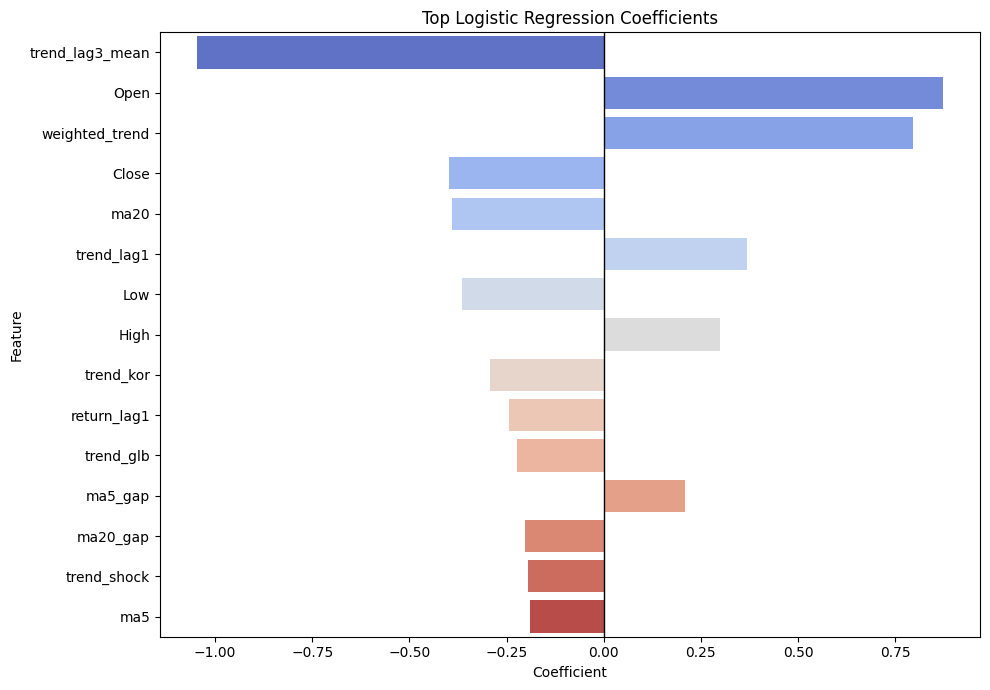

,feature,coefficient,abs_coefficient
20,trend_lag3_mean,-1.045928,1.045928
7,Open,0.872311,0.872311
3,weighted_trend,0.796221,0.796221
4,Close,-0.397474,0.397474
16,ma20,-0.389498,0.389498
19,trend_lag1,0.369719,0.369719
6,Low,-0.365138,0.365138
5,High,0.298843,0.298843
0,trend_kor,-0.293321,0.293321
10,return_lag1,-0.244721,0.244721


In [14]:
coef_df = pd.DataFrame({
    "feature": trainer.features,
    "coefficient": final_model.coef_[0]
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
top_coef = coef_df.sort_values("abs_coefficient", ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_coef, y="feature", x="coefficient", palette="coolwarm")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

top_coef[["feature", "coefficient", "abs_coefficient"]]

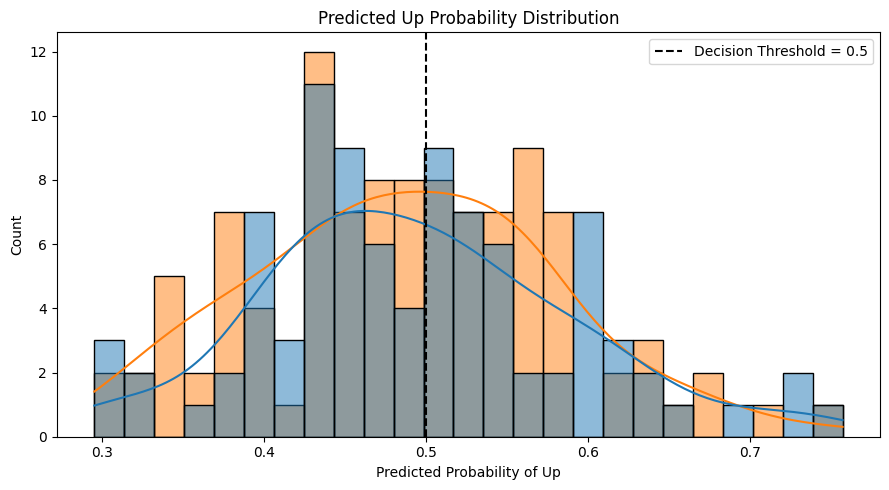

In [15]:
test_prob = final_model.predict_proba(X_test)[:, 1]
prob_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
    "prob_up": test_prob
})

plt.figure(figsize=(9, 5))
sns.histplot(data=prob_df, x="prob_up", hue="actual", bins=25, kde=True)
plt.axvline(0.5, linestyle="--", color="black", label="Decision Threshold = 0.5")
plt.title("Predicted Up Probability Distribution")
plt.xlabel("Predicted Probability of Up")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

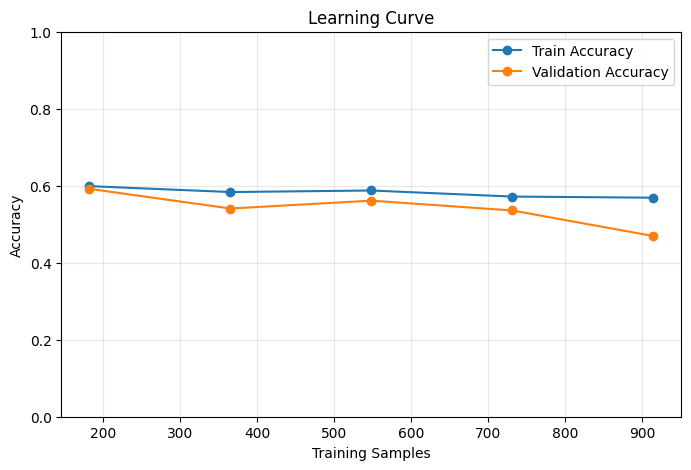

,train_size,train_accuracy,val_accuracy
0,182,0.598901,0.591837
1,365,0.583562,0.540816
2,548,0.587591,0.561224
3,731,0.571819,0.535714
4,914,0.568928,0.469388


In [16]:
train_sizes = np.linspace(0.2, 1.0, 5)
learning_rows = []

for frac in train_sizes:
    n_train = int(len(X_train) * frac)
    lc_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    lc_model.fit(X_train[:n_train], y_train.iloc[:n_train])
    learning_rows.append({
        "train_size": n_train,
        "train_accuracy": accuracy_score(y_train.iloc[:n_train], lc_model.predict(X_train[:n_train])),
        "val_accuracy": accuracy_score(y_val, lc_model.predict(X_val))
    })

learning_df = pd.DataFrame(learning_rows)

plt.figure(figsize=(8, 5))
plt.plot(learning_df["train_size"], learning_df["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(learning_df["train_size"], learning_df["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Learning Curve")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

learning_df

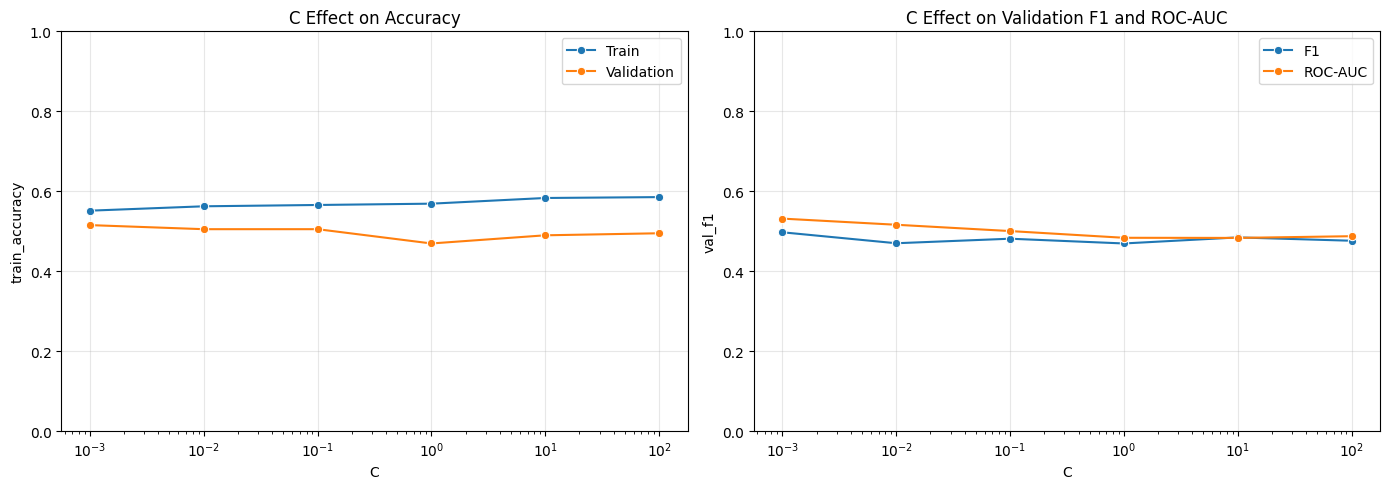

,C,train_accuracy,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,0.001,0.551422,0.515306,0.552941,0.451923,0.497354,0.531564
1,0.010,0.562363,0.505102,0.544304,0.413462,0.469945,0.516200
2,0.100,0.565646,0.505102,0.542169,0.432692,0.481283,0.500418
3,1.000,0.568928,0.469388,0.500000,0.442308,0.469388,0.483591
4,10.000,0.583151,0.489796,0.522222,0.451923,0.484536,0.483278
5,100.000,0.585339,0.494898,0.529412,0.432692,0.476190,0.487563


In [17]:
c_values = [0.001, 0.01, 0.1, 1, 10, 100]
hyper_rows = []

for c in c_values:
    hp_model = LogisticRegression(
        C=c,
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
    hp_model.fit(X_train, y_train)
    val_pred = hp_model.predict(X_val)
    hyper_rows.append({
        "C": c,
        "train_accuracy": accuracy_score(y_train, hp_model.predict(X_train)),
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_precision": precision_score(y_val, val_pred, zero_division=0),
        "val_recall": recall_score(y_val, val_pred, zero_division=0),
        "val_f1": f1_score(y_val, val_pred, zero_division=0),
        "val_roc_auc": roc_auc_score(y_val, hp_model.predict_proba(X_val)[:, 1])
    })

hyper_df = pd.DataFrame(hyper_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=hyper_df, x="C", y="train_accuracy", marker="o", label="Train", ax=axes[0])
sns.lineplot(data=hyper_df, x="C", y="val_accuracy", marker="o", label="Validation", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("C Effect on Accuracy")
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)

sns.lineplot(data=hyper_df, x="C", y="val_f1", marker="o", label="F1", ax=axes[1])
sns.lineplot(data=hyper_df, x="C", y="val_roc_auc", marker="o", label="ROC-AUC", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("C Effect on Validation F1 and ROC-AUC")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

hyper_df

## 5. 단계적 성능 개선 실험

기준 모델을 바탕으로 정규화 강도, class weight, feature selection, decision threshold를 변경하며 성능 변화를 비교합니다.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix

def evaluate_step(name, model, threshold=0.5):
    model.fit(X_train_val, y_train_val)
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {
        "step": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1_score": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob),
        "confusion_matrix": confusion_matrix(y_test, pred).tolist()
    }

improvement_results = []

# Step 0. Baseline
improvement_results.append(evaluate_step(
    "Step 0 Baseline: C=1, class_weight=balanced",
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
))

# Step 1. Strong regularization without class weight
improvement_results.append(evaluate_step(
    "Step 1: C=0.001, class_weight=None",
    LogisticRegression(C=0.001, max_iter=1000, class_weight=None, random_state=42)
))

# Step 2. Feature selection + strong regularization
feature_select_model = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=12)),
    ("clf", LogisticRegression(C=0.001, max_iter=1000, class_weight="balanced", random_state=42))
])
improvement_results.append(evaluate_step(
    "Step 2: SelectKBest top12 + C=0.001",
    feature_select_model
))

# Step 3. Recall-oriented threshold tuning
threshold_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
improvement_results.append(evaluate_step(
    "Step 3: Baseline + threshold=0.32",
    threshold_model,
    threshold=0.32
))

improvement_df = pd.DataFrame(improvement_results)
improvement_df[["step", "threshold", "accuracy", "precision", "recall", "f1_score", "roc_auc", "confusion_matrix"]]


In [ ]:
plot_df = improvement_df.melt(
    id_vars="step",
    value_vars=["accuracy", "precision", "recall", "f1_score", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x="metric", y="score", hue="step")
plt.title("Stepwise Logistic Regression Improvement")
plt.ylim(0, 1)
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.45), ncol=2)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(improvement_results), figsize=(18, 4))
for ax, row in zip(axes, improvement_results):
    sns.heatmap(row["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(row["step"].split(":")[0])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 4. 모델 저장

In [18]:
trainer.save_model(final_model, "model1_logistic")

모델 저장 완료: c:\Users\nayeo\Desktop\기학기 팀플\Team_1\models\model1_logistic.joblib
